### install requirements

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Standardizing datasets

***Firstly, you should check if the dataset directory exists***

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Set dataset path
dataset_path = "data/mvtec_ad/bottle"  # The dataset root directory
image_folder = os.path.join(dataset_path, "test")  # Path to the test set
mask_folder = os.path.join(dataset_path, "ground_truth")  # Path to store ground truth masks
fg_mask_folder = os.path.join(dataset_path, "fg_mask")

assert os.path.exists(dataset_path), f"dataset root directory does not exist: {dataset_path}"
assert os.path.exists(image_folder), f"test set path does not exist: {image_folder}"
assert os.path.exists(mask_folder), f"ground truth masks do not exist: {mask_folder}, please create masks"
assert os.path.exists(fg_mask_folder), f"foreground masks do not exist: {fg_mask_folder}, please create foreground masks"

AssertionError: ground truth masks do not exist: data/mvtec_ad/bottle/ground_truth, please create masks

***if ground truth masks does not exist, please run the follow cell***

In [14]:
# function to generate the ground truth masks
def generate_mask(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    edges = cv2.Canny(blurred, threshold1=30, threshold2=150)
    _, mask = cv2.threshold(edges, 10, 225, cv2.THRESH_BINARY)
    return mask

if not os.path.exists(mask_folder):
    os.mkdir(mask_folder)
    print(f"Create ground truth directory: {mask_folder}")

# set the types of anomaly
anomaly_types = ["broken_large", "broken_small", "contamination"]

for i in anomaly_types:
    anomaly_folder = os.path.join(image_folder, i)
    image_files = [f for f in os.listdir(anomaly_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
    assert len(image_files) > 0, f"No images found in the test folder: {anomaly_folder}"

    for image_file in tqdm(image_files, desc="Processing images"):
        img_path = os.path.join(anomaly_folder, image_file)
        mask_drectory = os.path.join(mask_folder, i)
        mask_path = os.path.join(mask_drectory, image_file)

        if not os.path.exists(mask_drectory):
            os.mkdir(mask_drectory)

        mask = generate_mask(img_path)
        cv2.imwrite(mask_path, mask)
        print(f"Generated mask: {mask_path}")

print("All masks have been generated and saved")
    

Processing images:  40%|████      | 8/20 [00:00<00:00, 40.82it/s]

Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/007.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/004.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/000.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/001.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/006.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/014.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/017.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/003.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/012.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/016.png


Processing images: 100%|██████████| 20/20 [00:00<00:00, 44.19it/s]


Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/018.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/011.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/002.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/009.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/015.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/013.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/005.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/008.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/019.png
Generated mask: data/mvtec_ad/bottle/ground_truth/broken_large/010.png


Processing images:  23%|██▎       | 5/22 [00:00<00:00, 46.92it/s]

...

Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/016.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/018.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/011.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/002.png


Processing images:  71%|███████▏  | 15/21 [00:00<00:00, 37.69it/s]

Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/009.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/015.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/020.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/013.png


Processing images: 100%|██████████| 21/21 [00:00<00:00, 37.42it/s]

Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/005.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/008.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/019.png
Generated mask: data/mvtec_ad/bottle/ground_truth/contamination/010.png
All masks have been generated and saved


***if foreground masks does not exist, please run the follow cell***

Processing Images:   3%|▎         | 6/209 [00:00<00:08, 24.67it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/007.png
Generated mask: data/mvtec_ad/bottle/fg_mask/204.png
Generated mask: data/mvtec_ad/bottle/fg_mask/116.png
Generated mask: data/mvtec_ad/bottle/fg_mask/130.png
Generated mask: data/mvtec_ad/bottle/fg_mask/004.png
Generated mask: data/mvtec_ad/bottle/fg_mask/136.png


Processing Images:   4%|▍         | 9/209 [00:00<00:08, 23.78it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/031.png
Generated mask: data/mvtec_ad/bottle/fg_mask/096.png
Generated mask: data/mvtec_ad/bottle/fg_mask/097.png
Generated mask: data/mvtec_ad/bottle/fg_mask/101.png
Generated mask: data/mvtec_ad/bottle/fg_mask/150.png


Processing Images:   7%|▋         | 15/209 [00:00<00:08, 22.31it/s]

...

Generated mask: data/mvtec_ad/bottle/fg_mask/166.png
Generated mask: data/mvtec_ad/bottle/fg_mask/074.png
Generated mask: data/mvtec_ad/bottle/fg_mask/010.png
Generated mask: data/mvtec_ad/bottle/fg_mask/189.png
Generated mask: data/mvtec_ad/bottle/fg_mask/126.png


Processing Images:  98%|█████████▊| 205/209 [00:09<00:00, 22.45it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/156.png
Generated mask: data/mvtec_ad/bottle/fg_mask/094.png
Generated mask: data/mvtec_ad/bottle/fg_mask/192.png
Generated mask: data/mvtec_ad/bottle/fg_mask/141.png
Generated mask: data/mvtec_ad/bottle/fg_mask/089.png


Processing Images: 100%|██████████| 209/209 [00:10<00:00, 20.70it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/187.png
Generated mask: data/mvtec_ad/bottle/fg_mask/164.png
Generated mask: data/mvtec_ad/bottle/fg_mask/075.png
Generated mask: data/mvtec_ad/bottle/fg_mask/036.png
All masks have been generated and saved,


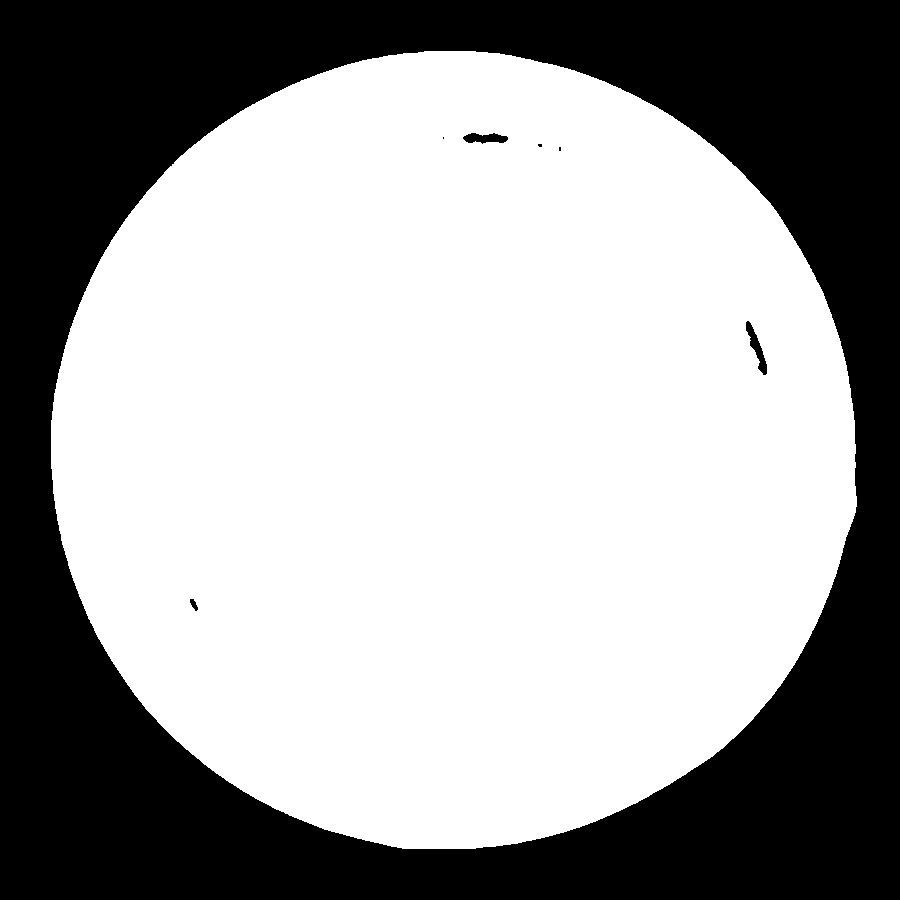

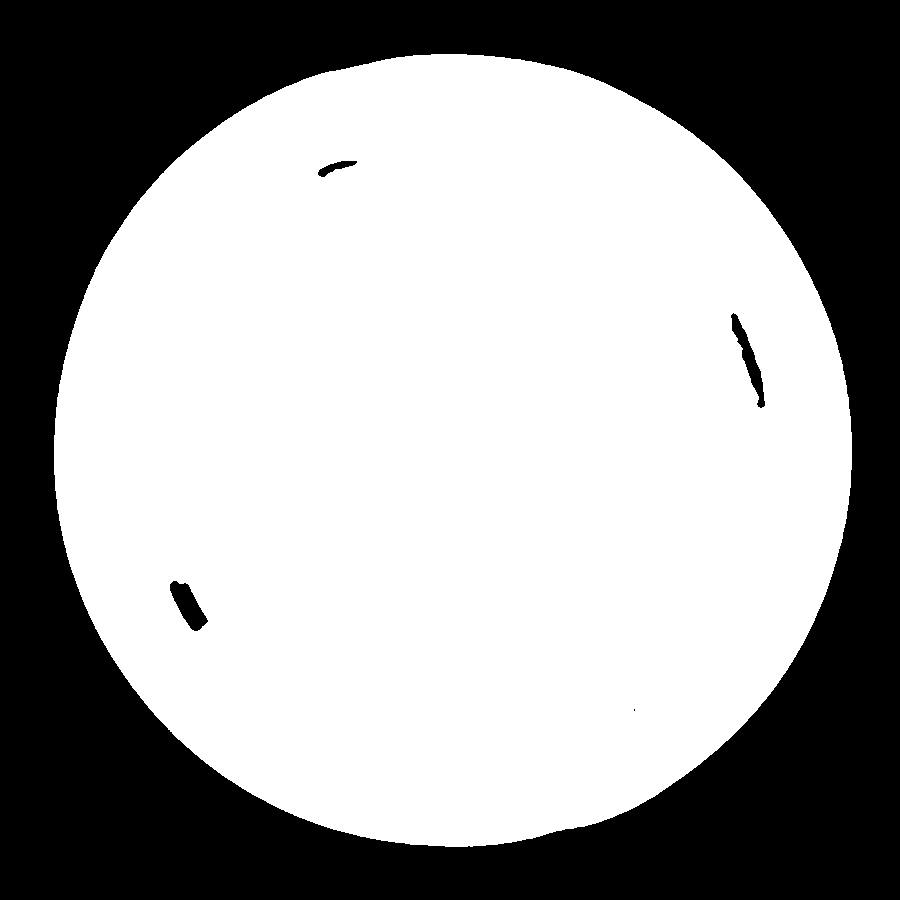

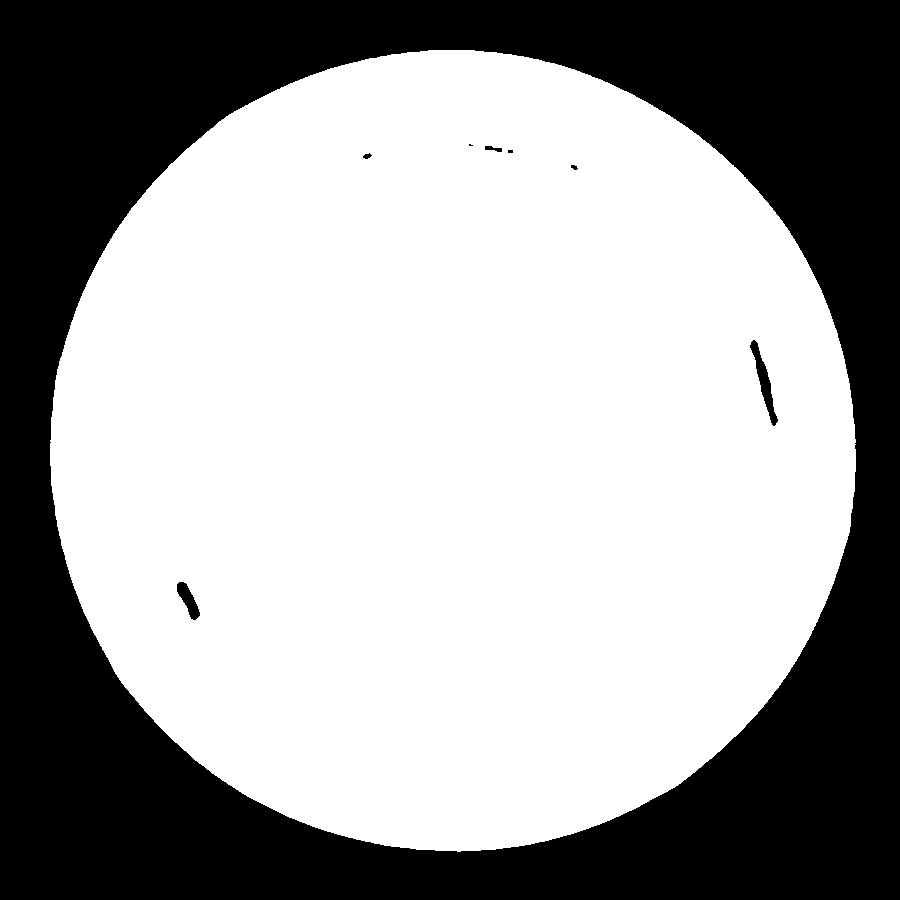

In [95]:
if not os.path.exists(fg_mask_folder):
    os.mkdir(fg_mask_folder)
    print(f"Created foreground mask folder: {fg_mask_folder}")

def generate_foreground_mask(image_path, output_path, filter_size=7):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Can not read the image")

    _, mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    h, w = mask.shape
    center = mask[h//2, w//2]
    mask = cv2.bitwise_not(mask) if center == 0 else mask
    mask = cv2.medianBlur(mask, filter_size)

    cv2.imwrite(output_path, mask)
    print(f"Generated mask: {output_path}")

image_path = os.path.join(dataset_path, "train/good")
image_files = [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
assert len(image_files) > 0, f"No images found in: {image_path}"

masks = []

for img in tqdm(image_files, desc="Processing Images"):
    mask_path = os.path.join(fg_mask_folder, img)
    masks.append(mask_path)
    img_path = os.path.join(image_path, img)
    generate_foreground_mask(img_path, mask_path)

print("All masks have been generated and saved,")

from IPython.display import Image, display
for i in range(3): # change this number to set how many figures you can see
    display(Image(masks[i]))

Processing Images:   3%|▎         | 6/209 [00:00<00:07, 25.89it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/007.png
Generated mask: data/mvtec_ad/bottle/fg_mask/204.png
Generated mask: data/mvtec_ad/bottle/fg_mask/116.png
Generated mask: data/mvtec_ad/bottle/fg_mask/130.png
Generated mask: data/mvtec_ad/bottle/fg_mask/004.png
Generated mask: data/mvtec_ad/bottle/fg_mask/136.png


Processing Images:   6%|▌         | 12/209 [00:00<00:07, 25.94it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/031.png
Generated mask: data/mvtec_ad/bottle/fg_mask/096.png
Generated mask: data/mvtec_ad/bottle/fg_mask/097.png
Generated mask: data/mvtec_ad/bottle/fg_mask/101.png
Generated mask: data/mvtec_ad/bottle/fg_mask/150.png
Generated mask: data/mvtec_ad/bottle/fg_mask/021.png


Processing Images:   9%|▊         | 18/209 [00:00<00:07, 26.24it/s]

...

Generated mask: data/mvtec_ad/bottle/fg_mask/156.png
Generated mask: data/mvtec_ad/bottle/fg_mask/094.png
Generated mask: data/mvtec_ad/bottle/fg_mask/192.png
Generated mask: data/mvtec_ad/bottle/fg_mask/141.png


Processing Images: 100%|█████████▉| 208/209 [00:12<00:00, 16.10it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/089.png
Generated mask: data/mvtec_ad/bottle/fg_mask/187.png
Generated mask: data/mvtec_ad/bottle/fg_mask/164.png
Generated mask: data/mvtec_ad/bottle/fg_mask/075.png


Processing Images: 100%|██████████| 209/209 [00:12<00:00, 17.14it/s]


Generated mask: data/mvtec_ad/bottle/fg_mask/036.png
All masks have been generated and saved,


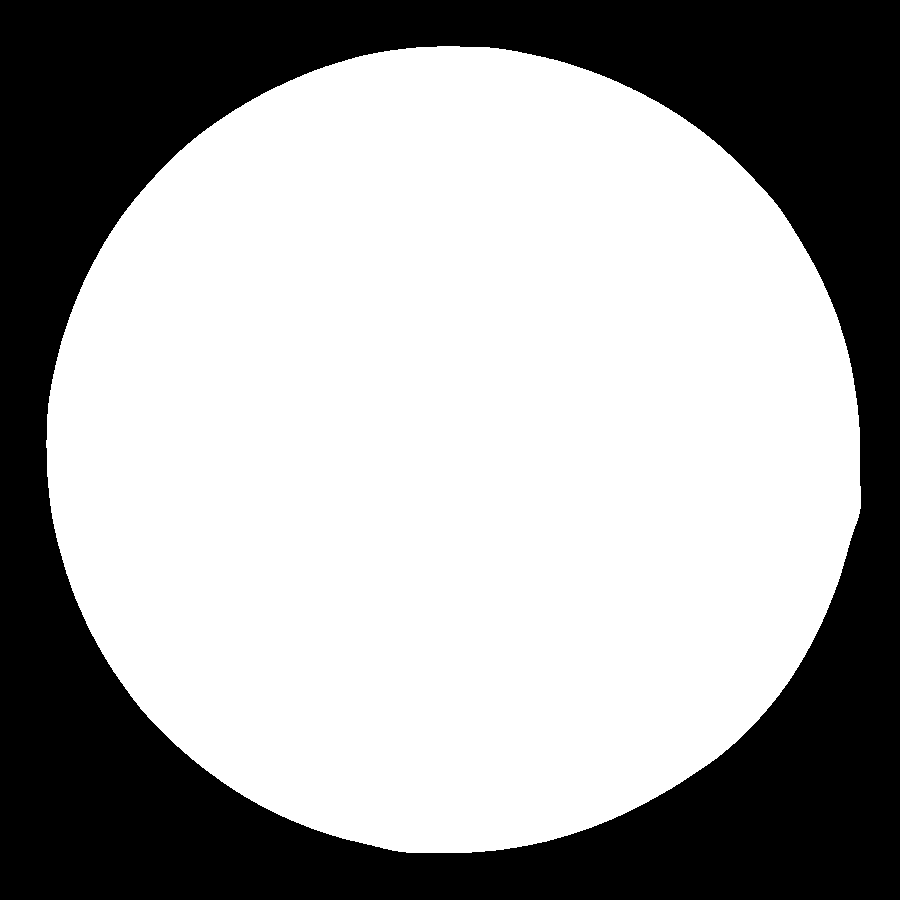

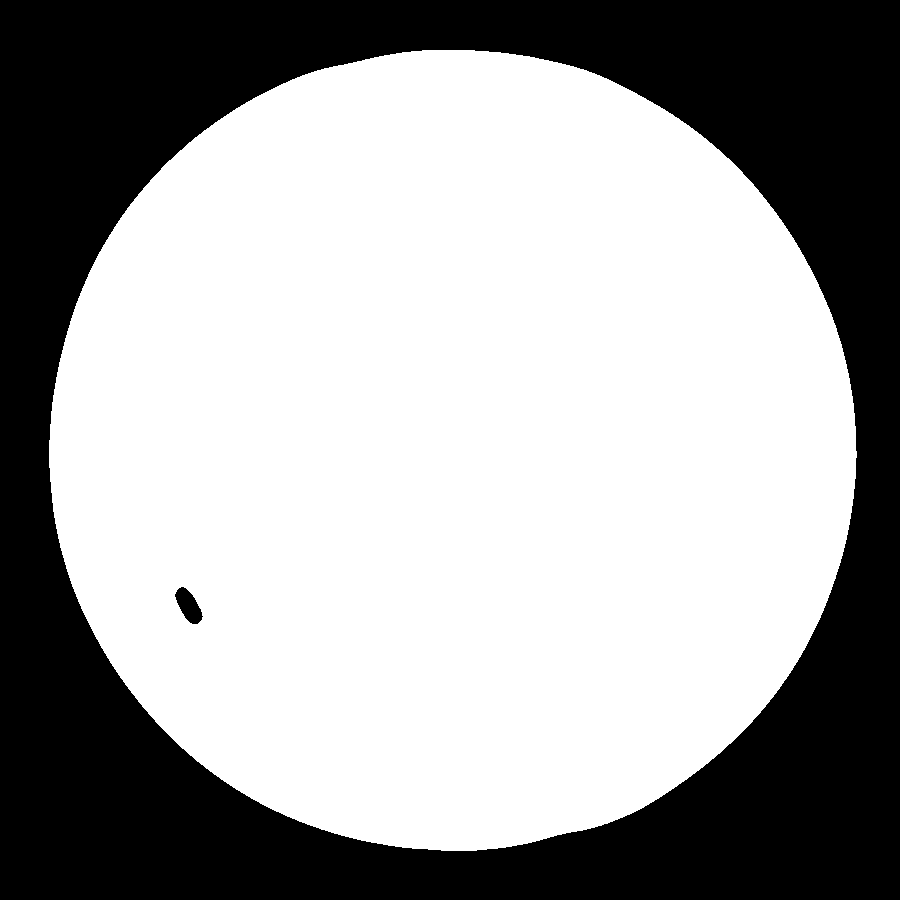

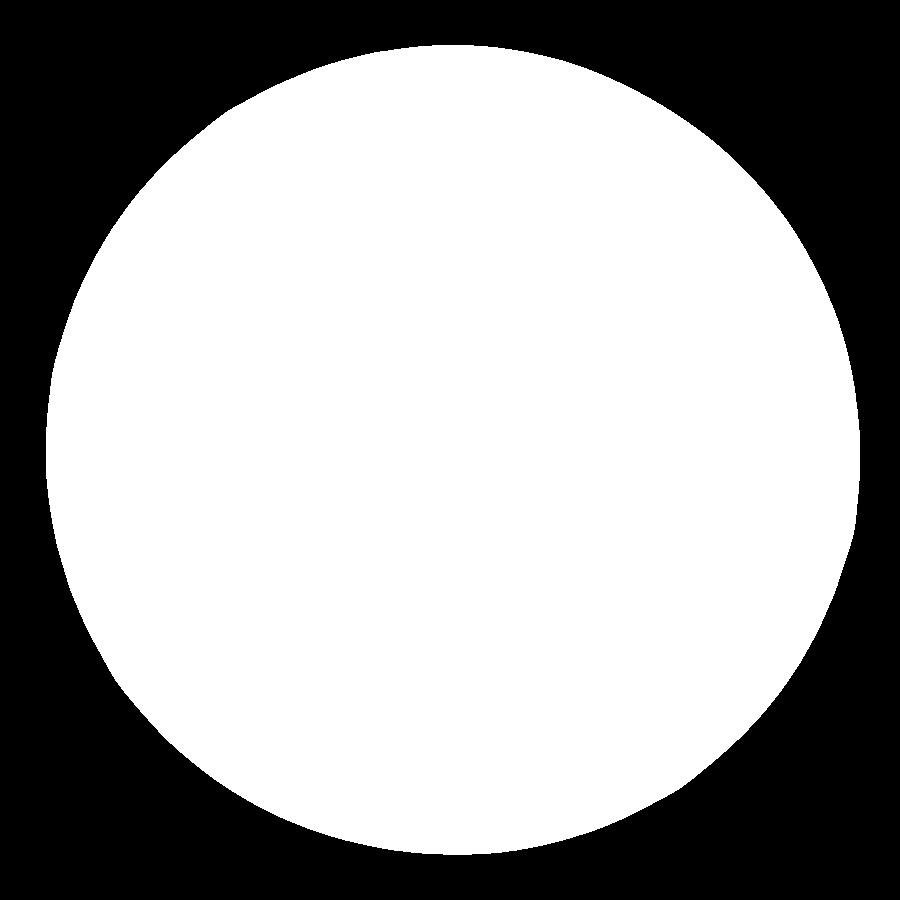

In [96]:
if not os.path.exists(fg_mask_folder):
    os.mkdir(fg_mask_folder)
    print(f"Created foreground mask folder: {fg_mask_folder}")

def get_background_color(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    background_color = np.argmax(hist)
    return background_color

def get_background_threshold(image, scale_factor=0.5):
    std_dev = np.std(image)
    threshold = std_dev * scale_factor
    return int(threshold)

def generate_foreground_mask(image_path, output_path, filter_size=21):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Can not read the image")

    mask = np.ones_like(image, dtype=np.uint8) * 255
    bg_color = get_background_color(image)
    bg_threshold = get_background_threshold(image)

    diff = np.abs(image.astype(np.int16) - bg_color)
    mask &= np.uint8(diff > bg_threshold) * 255

    mask = cv2.medianBlur(mask, filter_size)

    cv2.imwrite(output_path, mask)
    print(f"Generated mask: {output_path}")

image_path = os.path.join(dataset_path, "train/good")
image_files = [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
assert len(image_files) > 0, f"No images found in: {image_path}"

masks = []

for img in tqdm(image_files, desc="Processing Images"):
    mask_path = os.path.join(fg_mask_folder, img)
    masks.append(mask_path)
    img_path = os.path.join(image_path, img)
    generate_foreground_mask(img_path, mask_path)

print("All masks have been generated and saved,")

from IPython.display import Image, display
for i in range(3): # change this number to set how many figures you can see
    display(Image(masks[i]))

Processing Images:   0%|          | 1/209 [00:00<00:50,  4.11it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/007.png


Processing Images:   1%|          | 2/209 [00:00<00:48,  4.29it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/204.png


Processing Images:   1%|▏         | 3/209 [00:00<00:48,  4.25it/s]

...

Generated mask: data/mvtec_ad/bottle/fg_mask/089.png


Processing Images:  99%|█████████▉| 207/209 [00:41<00:00,  4.02it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/187.png
Generated mask: data/mvtec_ad/bottle/fg_mask/164.png


Processing Images: 100%|██████████| 209/209 [00:41<00:00,  5.02it/s]

Generated mask: data/mvtec_ad/bottle/fg_mask/075.png
Generated mask: data/mvtec_ad/bottle/fg_mask/036.png
All masks have been generated and saved,


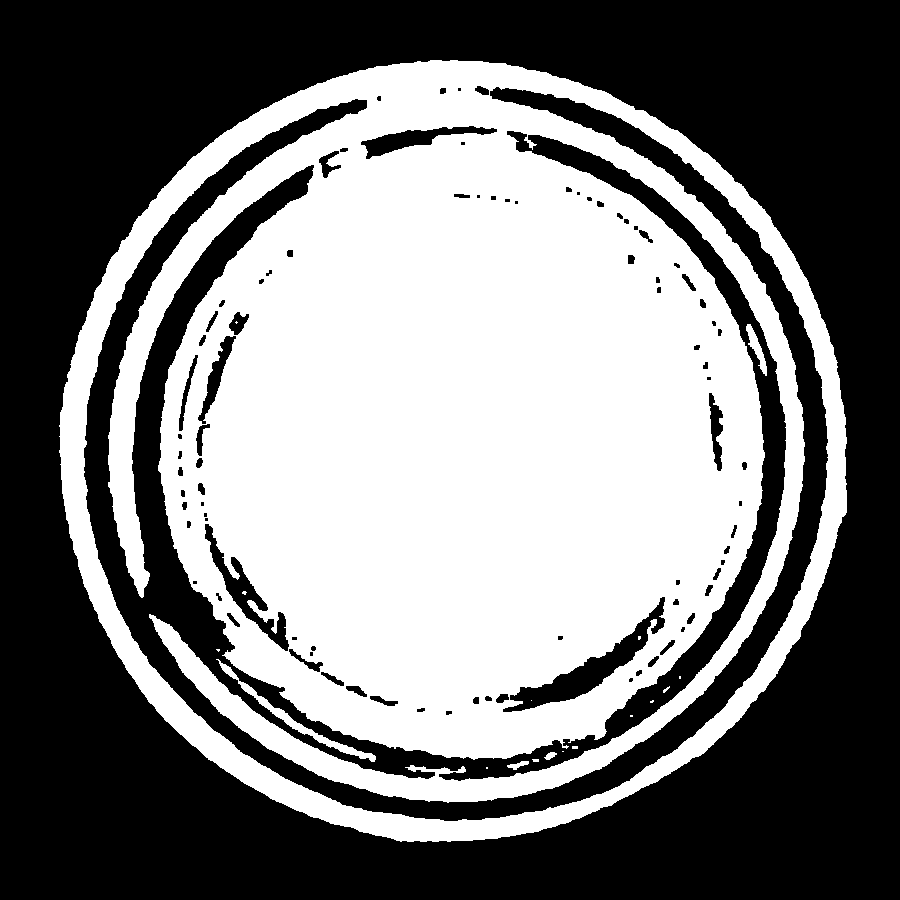

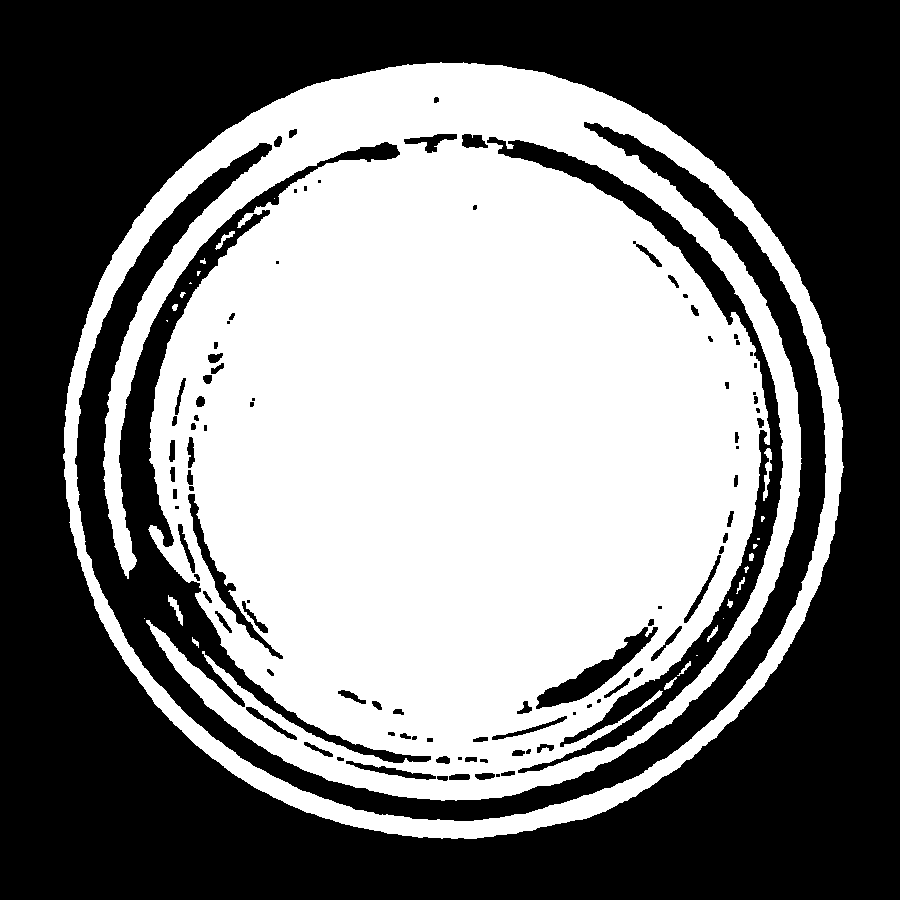

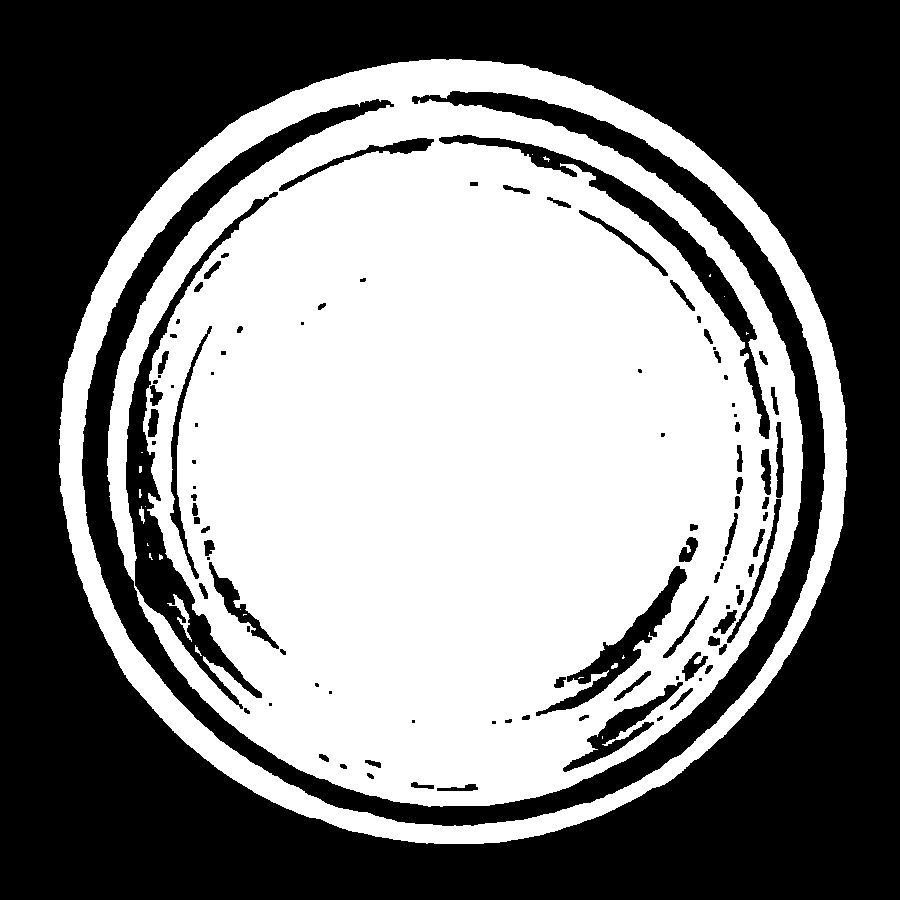

In [ ]:
from sklearn.cluster import MiniBatchKMeans

def generate_foreground_mask(image_path, output_path, std_multiplier=0.5, filter_size=7, downsample_ratio=0.25):
    image = cv2.imread(image_path)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    h, w = lab.shape[:2]
    small_lab = cv2.resize(lab, (int(w*downsample_ratio), int(h*downsample_ratio)))

    pixels = small_lab.reshape(-1, 3).astype(np.float32)
    kmeans = MiniBatchKMeans(n_clusters=2, random_state=0, n_init=3)
    labels = kmeans.fit_predict(pixels)

    cluster_points = [pixels[labels==i] for i in range(2)]
    spatial_vars = []
    for i in range(2):
        coords = np.argwhere(labels.reshape(small_lab.shape[:2]) // downsample_ratio)
        spatial_vars.append(np.var(coords))
    bg_cluster = np.argmax(spatial_vars) 
    
    bg_pixels = cluster_points[bg_cluster]
    mean = np.mean(bg_pixels, axis=0)
    std = np.std(bg_pixels, axis=0)
    
    cov = np.cov(bg_pixels.T)
    inv_cov = np.linalg.pinv(cov)
    diff = lab.reshape(-1,3) - mean
    distances = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    
    threshold = np.mean(distances) + std_multiplier * np.std(distances)
    mask = (distances > threshold).reshape(h, w).astype(np.uint8) * 255
    
    mask = cv2.medianBlur(mask, filter_size)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    
    cv2.imwrite(output_path, mask)
    print(f"Generated mask: {output_path}")

image_path = os.path.join(dataset_path, "train/good")
image_files = [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
assert len(image_files) > 0, f"No images found in: {image_path}"

masks = []

for img in tqdm(image_files, desc="Processing Images"):
    mask_path = os.path.join(fg_mask_folder, img)
    masks.append(mask_path)
    img_path = os.path.join(image_path, img)
    generate_foreground_mask(img_path, mask_path)

print("All masks have been generated and saved,")

from IPython.display import Image, display
for i in range(3): # change this number to set how many figures you can see
    display(Image(masks[i]))

### run training

In [ ]:
## datapath: mvtec ad dataset structure, put downloaded foreground masks in this file folder, named fg_mask
## augpath: augmented dtd dataset
## results_path: where the results are saved
## /mlruns: where mlflow tracking results are saved by default
## meta_epochs: 640 (set to be 5 here for faster training, 100 maybe enough)

In [3]:
%cd data/mvtec_ad
!ls
%cd ../..

/home/qjh/glass/GLASS-main/data/mvtec_ad
bottle	 carpet   hazelnut     metal_nut   screw       transistor
cable	 fg_mask  leather      pill	   tile        wood
capsule  grid	  license.txt  readme.txt  toothbrush  zipper
/home/qjh/glass/GLASS-main


In [11]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('screw')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test ckpt \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 8 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

INFO:__main__:Command line arguments: main.py --results_path ./results --gpu 0 --seed 0 --test ckpt net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 5 --eval_epochs 1 --dsc_layers 2 --dsc_hidden 1024 --pre_proj 1 --mining 1 --noise 0.015 --radius 0.75 --p 0.5 --step 20 --limit 392 dataset --distribution 0 --mean 0.5 --std 0.1 --fg 1 --rand_aug 1 --batch_size 8 --resize 288 --imagesize 288 -d screw mvtec ./data/mvtec_ad ./data/dtd/images
INFO:__main__:Dataset        SCREW        : train=320 test=160


INFO:__main__:Selecting dataset [mvtec_screw] (1/1) 2025-02-14 02:59:49
epoch:0 discriminator loss:1.19e+00 pt:90.93 pf:59.38 rt:1.97 rg:2.08 rf:3.48 svd:1 sample:320:   0%|          | 0/5 [01:49<?, ?epoch/s]
Inferring...: 100%|██████████| 20/20 [00:09<00:00,  2.27batch/s]
epoch:1 discriminator loss:9.77e-01 pt:93.21 pf:60.96 rt:1.86 rg:1.99 rf:3.41 svd:1 sample:320 IAUC:52.18(52.18) PAUC: Do not have PAUC) IF1-max:85.3(85.3) E:0(0):  20%|██        | 1/5 [03:47<08:08, 122.17s/epoch]
Inferring...: 100%|██████████| 20/20 [00:09<00:00,  2.57batch/s]
epoch:2 discriminator loss:9.29e-01 pt:93.09 pf:62.88 rt:1.77 rg:1.89 rf:3.41 svd:1 sample:320 IAUC:65.26(65.26) PAUC: Do not have PAUC) IF1-max:85.3(85.3) E:1(1):  40%|████      | 2/5 [05:48<06:03, 121.14s/epoch]
Inferring...: 100%|██████████| 20/20 [00:07<00:00,  3.01batch/s]
epoch:3 discriminator loss:8.89e-01 pt:93.49 pf:65.35 rt:1.66 rg:1.79 rf:3.31 svd:1 sample:320 IAUC:70.9(70.9) PAUC: Do not have PAUC) IF1-max:85.3(85.3) E:2(2):  60%|█

image_auroc:75.88 image_ap:89.57 image_f1_max:86.76 f1_max_threshold:19.37 best_epoch:4




### run test

In [11]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('capsule' 'pill' 'screw')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test test \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 16 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

INFO:__main__:Command line arguments: main.py --results_path ./results --gpu 0 --seed 0 --test test net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 5 --eval_epochs 1 --dsc_layers 2 --dsc_hidden 1024 --pre_proj 1 --mining 1 --noise 0.015 --radius 0.75 --p 0.5 --step 20 --limit 392 dataset --distribution 0 --mean 0.5 --std 0.1 --fg 1 --rand_aug 1 --batch_size 16 --resize 288 --imagesize 288 -d capsule -d pill -d screw mvtec ./data/mvtec_ad ./data/dtd/images
INFO:__main__:Dataset       CAPSULE       : train=0 test=132
INFO:__main__:Dataset         PILL        : train=0 test=167
INFO:__main__:Dataset        SCREW        : train=0 test=160
INFO:__main__:Selecting dataset [mvtec_capsule] (1/3) 2025-02-08 14:29:23



Inferring...: 100%|██████████| 9/9 [00:04<00:00,  2.99batch/s]
                                                              
INFO:__main__:Selecting dataset [mvtec_pill] (2/3) 2025-02-08 14:30:03


image_auroc:94.65 image_ap:98.78 pixel_auroc:94.98 pixel_ap:36.96 pixel_pro:88.44 image_f1_max:96.4 f1_max_threshold:15.21 best_epoch:4





Inferring...: 100%|██████████| 11/11 [00:05<00:00,  2.65batch/s]
                                                                
INFO:__main__:Selecting dataset [mvtec_screw] (3/3) 2025-02-08 14:30:56


image_auroc:91.41 image_ap:98.43 pixel_auroc:95.11 pixel_ap:73.04 pixel_pro:94.31 image_f1_max:93.29 f1_max_threshold:23.28 best_epoch:4


image_auroc:55.97 image_ap:80.51 pixel_auroc:91.17 pixel_ap:5.86 pixel_pro:71.81 image_f1_max:85.3 f1_max_threshold:0.0 best_epoch:3





Inferring...: 100%|██████████| 10/10 [00:05<00:00,  2.32batch/s]


### observe results

In [ ]:
## results/models: saved model weights
## eval: each image contains three parts from left to right: input image, groundtruth, predicted heatmap
## results.csv: evaluation results on all metrics for each category and the mean of them

In [18]:
%cd results
!ls

/home/ting/GLASS/results
eval  models  results.csv  training


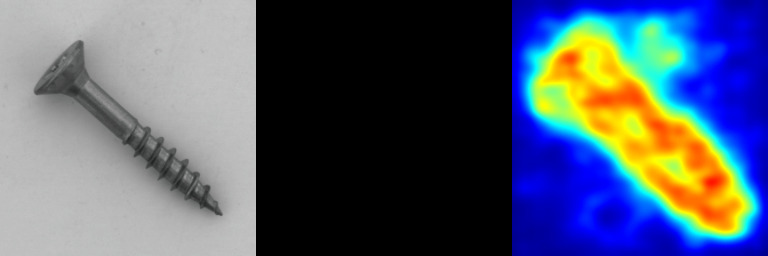

In [19]:
from IPython.display import Image, display
display(Image('eval/mvtec_screw/001.png'))